In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Import required libraries and configure display settings
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import sqlalchemy as sa
from datetime import date

# Disable scientific notation for float display
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Load the analytical dataset from the intermediate data layer
# ─────────────────────────────────────────────
# Load the pre-processed analytical table from the pickle file
df = pd.read_pickle('../datos/intermedios/tablon_analitico.pickle')

In [6]:
df.head()

,usuario,sesion,evento,producto,precio,categoria,año,año_nuevo_ruso,black_friday,cyber_monday,...,festivo,hora,mes,navidad_occidental,navidad_ortodoxa,nombre_dia,pre_año_nuevo,san_valentin,semana_año,trimestre
fecha_hora,,,,,,,,,,,,,,,,,,,,,
2019-10-01 00:01:46+00:00,462033176,a18e0999-61a1-4218-8f8f-61ec1d375361,view,5843665,9.44,1487580005092295511,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:01:55+00:00,514753614,e2fecb2d-22d0-df2c-c661-15da44b3ccf1,cart,5868461,3.57,1487580013069861041,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:02:50+00:00,527418424,86e77869-afbc-4dff-9aa2-6b7dd8c90770,view,5877456,122.22,1487580006300255120,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:03:41+00:00,555448072,b5f72ceb-0730-44de-a932-d16db62390df,view,5649270,6.19,1487580013749338323,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4
2019-10-01 00:03:44+00:00,552006247,2d8f304b-de45-4e59-8f40-50c603843fe5,view,18082,16.03,1487580005411062629,2019,0,0,0,...,0,0,10,0,0,Tuesday,0,0,40,4


In [7]:
# ─────────────────────────────────────────────
# PURPOSE: Calculate conversion rates between funnel stages (view → cart → remove → purchase)
# ─────────────────────────────────────────────

# Count events per type; reindex ensures all four stages appear even if missing in the data
eventos = df['evento'].value_counts().reindex(
    ['view', 'cart', 'remove_from_cart', 'purchase'],
    fill_value=0
)

# Build a conversion rate Series using 'view' as the base (= 100%)
# Guard against division by zero with conditional expressions
analisis_eventos = pd.Series({
    'view': 100,
    'cart/view (%)': (eventos['cart'] / eventos['view'] * 100) if eventos['view'] != 0 else 0,                          # % of views that added to cart
    'remove_from_cart/cart (%)': (eventos['remove_from_cart'] / eventos['cart'] * 100) if eventos['cart'] != 0 else 0,  # % of carts that were removed
    'purchase/cart (%)': (eventos['purchase'] / eventos['cart'] * 100) if eventos['cart'] != 0 else 0                   # % of carts that converted to purchase
}).round(2)

analisis_eventos

view                        100.00
cart/view (%)                59.75
remove_from_cart/cart (%)    71.42
purchase/cart (%)            22.20
dtype: float64

In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Build the conversion funnel DataFrame with cumulative percentages relative to views
# ─────────────────────────────────────────────

# All percentages are expressed relative to total views (base = 100%)
# 'remove_from_cart' and 'purchase' are chained through the cart stage to get cumulative rates
df_funnel = pd.DataFrame({
    'fase': ['Visualizaciones', 'Añadir a carrito', 'Sacar de carrito', 'Comprar'],
    'porcentaje': [
        100.00,                                                                                          # Base: 100% of views
        analisis_eventos['cart/view (%)'],                                                               # % of views that added to cart
        analisis_eventos['cart/view (%)'] * analisis_eventos['remove_from_cart/cart (%)'] / 100,        # Cumulative: cart rate × remove rate
        analisis_eventos['cart/view (%)'] * analisis_eventos['purchase/cart (%)'] / 100                 # Cumulative: cart rate × purchase rate
    ]
})

df_funnel

,fase,porcentaje
0,Visualizaciones,100.00
1,Añadir a carrito,59.75
2,Sacar de carrito,42.67
3,Comprar,13.26


In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Visualize the conversion funnel using an interactive Plotly chart
# ─────────────────────────────────────────────
import plotly.graph_objects as go

# Create a funnel chart; textinfo shows both the raw value and % relative to the first stage
fig = go.Figure(go.Funnel(
    y = df_funnel['fase'],         # Funnel stage labels (vertical axis)
    x = df_funnel['porcentaje'],   # Cumulative percentage values (horizontal axis)
    textinfo = "value+percent initial"
))

fig.update_layout(
    title = "Embudo de Conversión",
    height = 500
)

fig.show()

In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Pivot event counts per session to analyse user behaviour at session level
# ─────────────────────────────────────────────
# Group by session and event type, count products; unstack creates one column per event type
# Missing combinations (e.g. a session with no purchases) are filled with 0
sesiones = df.groupby(['sesion', 'evento']).producto.count().unstack(fill_value=0)
sesiones.head()

evento,cart,purchase,remove_from_cart,view
sesion,,,,
0000597b-de39-4a77-9fe5-02c8792ca14e,0,0,0,3
0000645a-8160-4a3d-91bf-154bff0a22e3,0,0,0,2
000090e1-da13-42b1-a31b-91a9ee5e6a88,0,0,0,1
0000b3cb-5422-4bf2-b8fe-5c1831d0dc1b,0,0,0,1
0000de26-bd58-42c9-9173-4763c76b398e,0,0,0,1


In [11]:
sesiones.mean().round(2)

evento
cart               1.29
purchase           0.29
remove_from_cart   0.92
view               2.16
dtype: float64

In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Reorder session columns to follow the natural funnel sequence
# ─────────────────────────────────────────────
# Keep only the four funnel-stage columns in logical order (view → cart → remove → purchase)
sesiones = sesiones[['view', 'cart', 'remove_from_cart', 'purchase']]

In [13]:
sesiones.mean().round(2)


evento
view               2.16
cart               1.29
remove_from_cart   0.92
purchase           0.29
dtype: float64

**Insight 1:**

Datos actuales de los principales eventos que nos sirven de baseline para futuras acciones de mejora

view 2.16

cart 1.29

remove_from_cart 0.92

purchase 0.29 

In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Aggregate event counts by hour of day to detect temporal activity patterns
# ─────────────────────────────────────────────
# Group by hour and event type; unstack pivots event types into separate columns
eventos_horas = df.groupby(['hora', 'evento']).producto.count().unstack(fill_value=0)
eventos_horas.head()

evento,cart,purchase,remove_from_cart,view
hora,,,,
0,6475,962,3238,8731
1,5555,1128,3930,7280
2,6433,1220,3509,8378
3,8544,1535,5331,11807
4,11242,2389,8095,18365


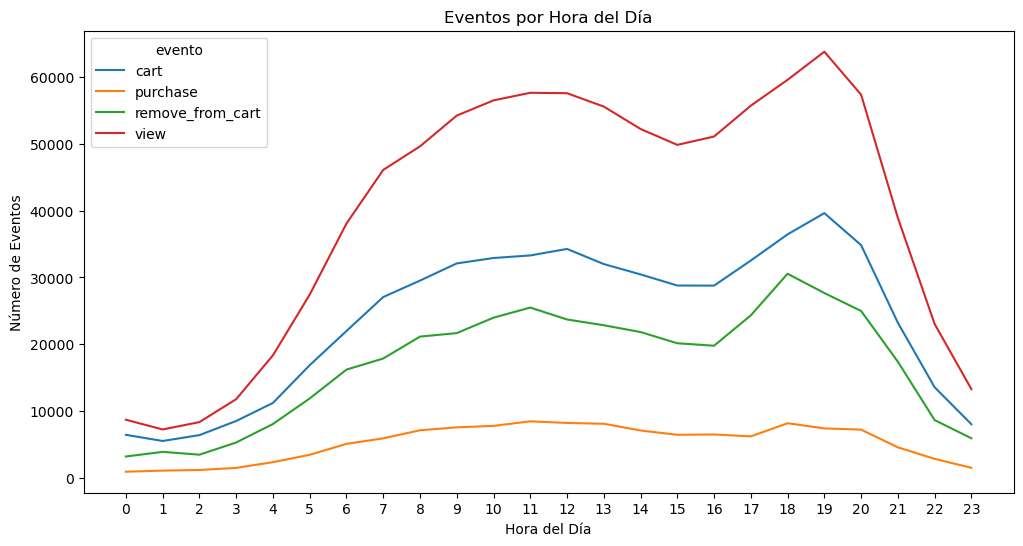

In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Plot all event types by hour of day to identify activity peaks across the day
# ─────────────────────────────────────────────
eventos_horas.plot(kind='line', figsize=(12, 6))
plt.title('Eventos por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Número de Eventos')
plt.xticks(range(24))   # Force all 24 hour ticks on the x-axis
plt.show()

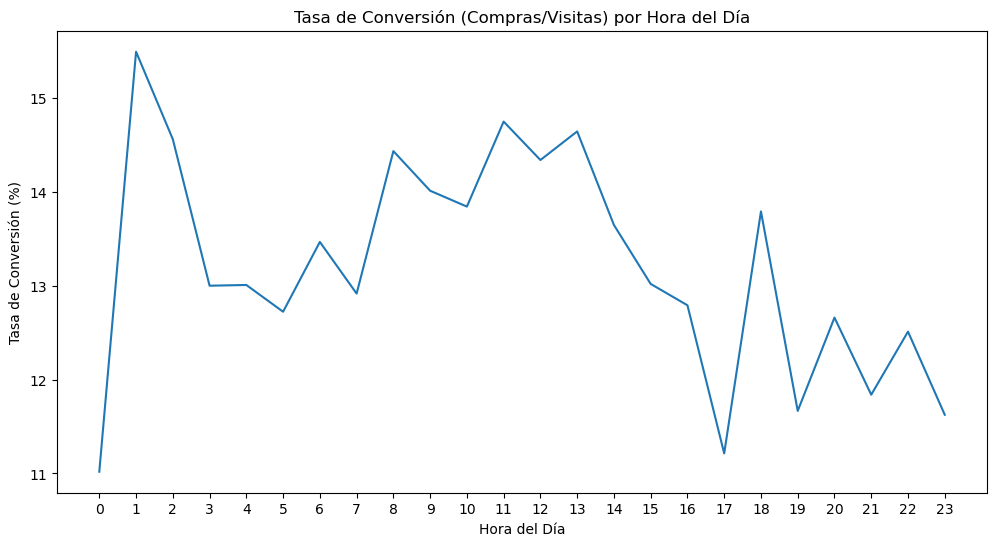

In [ ]:
# ─────────────────────────────────────────────
# PURPOSE: Calculate and plot the hourly purchase-to-view conversion rate
# ─────────────────────────────────────────────

# Compute conversion rate: number of purchases divided by number of views per hour (as %)
eventos_horas['compras_visitas'] = eventos_horas['purchase'] / eventos_horas['view'] * 100

# Plot the hourly conversion rate to identify the best-converting hours of the day
eventos_horas['compras_visitas'].plot(kind='line', figsize=(12, 6))
plt.title('Tasa de Conversión (Compras/Visitas) por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Tasa de Conversión (%)')
plt.xticks(range(24))   # Force all 24 hour ticks on the x-axis
plt.show()